# 二次構造予測後のスコアのグラフ化

## 準備

In [1]:
!pip install --quiet seaborn 
!pip install --quiet py7zr 
!pip install --quiet tables

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
import requests
import os
import zipfile
import py7zr
import warnings
warnings.filterwarnings('ignore')

REPO_URL="https://raw.githubusercontent.com/sinc-lab/rna-llm-folding/refs/heads/main"
DATA_PATH=f"{REPO_URL}/data"
RESULTS_PATH=f"{REPO_URL}/results"

os.chdir(
    "/workspaces/MLMvsData2vec/"
)  # 変更したいディレクトリのパスを指定
# 現在の作業ディレクトリを確認
print("Current working directory:", os.getcwd())

output_dir = Path("results/notebook/visualize_famfold")

Current working directory: /workspaces/MLMvsData2vec


### フレームワークについての設定

In [2]:
# フレームワークとカラーの設定
# frameworks = ["data2vec_mlm", "data2vec", "mlm", "rinalmo"]
frameworks = ["data2vec_mlm", "data2vec", "mlm"]

framework_colors = {
    "data2vec_mlm": "green",
    "data2vec": "orange",
    "mlm": "blue",
    "rinalmo": "gray",
}

# パスの設定
results_dir = Path("./results/SS_results/ArchiveII_famfold/")
result_paths = {
    "data2vec_mlm": results_dir / "data2vec/20260307T153057/knotfold/20260402T000234/overall_results.csv",
    "data2vec": results_dir / "data2vec/20260324T045257/knotfold/20260403T071832/overall_results.csv",
    "mlm": results_dir / "mlm/20260316T030756/knotfold/20260404T123256/overall_results.csv",
}

### dataframeの読み込み

In [3]:
# dataframeの読み込み
result_dfs = {
    "data2vec_mlm": pd.read_csv(result_paths["data2vec_mlm"]),
    "data2vec": pd.read_csv(result_paths["data2vec"]),
    "mlm": pd.read_csv(result_paths["mlm"]),
}

ArchiveII_df = pd.read_csv("./data/SS_data/ArchiveII.csv", header=0)

In [7]:
# ファミリーの設定
family = result_dfs["mlm"].family.unique().tolist()

num_seqs_for_family = {
    fam: result_dfs["mlm"].loc[result_dfs["mlm"].family == fam, "id"].nunique()
    for fam in family
}

print(family)
print(num_seqs_for_family)

['5s', 'tmRNA', 'tRNA', 'srp', 'grp1', 'RNaseP', '23s', 'telomerase', '16s']
{'5s': 1283, 'tmRNA': 462, 'tRNA': 557, 'srp': 918, 'grp1': 74, 'RNaseP': 454, '23s': 15, 'telomerase': 35, '16s': 66}


### 長さの分布と配列同士の距離の分布

In [8]:
# 長さの分布を表示する用にファミリーごとの長さについてのデータフレームを作成
ArchiveII_df['family'] = ArchiveII_df['id'].str.split('_', expand=True)[0]
ArchiveII_df.loc[:,['family','len']]

lengths = dict()
for fam in set(ArchiveII_df.family):
  lengths[fam] = ArchiveII_df.loc[ArchiveII_df.family==fam, 'len'].values

In [11]:
# 配列同士の距離の分布を計算する用
def download_and_uncompress_7z(url):
  response = requests.get(url)
  response.raise_for_status()

  temp_dir = os.path.join(os.getcwd(), "temp")
  os.makedirs(temp_dir, exist_ok=True)

  temp_7z_file = os.path.join(temp_dir, "temp.7z")
  with open(temp_7z_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024):
      if chunk:
        f.write(chunk)

  with py7zr.SevenZipFile(temp_7z_file, "r") as zip_ref:
    zip_ref.extractall(output_dir)
  os.remove(temp_7z_file)
  os.rmdir(temp_dir)
  
download_and_uncompress_7z("https://github.com/sinc-lab/rna-llm-folding/raw/refs/heads/main/data/ArchiveII_rnadist_f_all.7z")
# download_and_uncompress_7z("https://github.com/sinc-lab/rna-llm-folding/raw/refs/heads/main/data/ArchiveII_seqsim_f_all.7z")
rnadist = pd.read_hdf(f"ArchiveII_rnadist_f_all.h5")
#rnadist = pd.read_hdf(f"ArchiveII_seqsim_f_all.h5")

family_by_seq = np.array([f.split('_')[0] for f in rnadist.columns.to_list()])

unique_families = np.unique(family_by_seq)

distance = dict()
for fam in unique_families:
  idx_family = np.where(family_by_seq==fam)[0]
  idx_not_family = np.where(family_by_seq!=fam)[0]

  # min distance to train
  distance[fam] = rnadist.iloc[idx_family, idx_not_family].values.min(axis=1)

  # max similarity to train
  #distance[fam] = rnadist.iloc[idx_family, idx_not_family].values.max(axis=1)

### ベースラインの読み込み

In [12]:
# ベースラインの読み込み
famfold_df = pd.read_csv(f"{RESULTS_PATH}/ArchiveII_famfold/baseline_scores.csv")
medians = famfold_df.groupby('fam').median()
medians

,F1
fam,
16s,0.658618
23s,0.692308
5s,0.783784
RNaseP,0.578431
grp1,0.611402
srp,0.680000
tRNA,0.755556
telomerase,0.506024
tmRNA,0.378078


### Plot用の関数

In [29]:
def boxplot_kde(fam='5s', K=60, palette='red'):

  tam_w = 5.5 # fig width
  tam_h = 5.5 # fig height

  #===================================================
  # KMEANS
  from sklearn.cluster import KMeans
  import matplotlib
  matplotlib.rc('axes', edgecolor='gray')


  #===================================================
  # SORT METHOD BY MEDIAN
  method = []
  median = np.zeros(len(frameworks))

  for i,framework in enumerate(frameworks):
    method.append(framework)
    median[i] = np.median(result_dfs[framework].loc[result_dfs[framework].family==fam, 'f1'].values)

#   methods = [method[i] for i in median.argsort()[::-1]]
    methods = method

  colors = [framework_colors[m] for m in methods]
  #===================================================


  #===================================================
  # EXTRACT F1 VALUES BY METHOD
  f1 = [] # 全部のF1値を入れるリスト
  f1_swarm = [] # swarmplotに入れる値を入れるリスト（KMeansでクラスタリングした値を入れる）
  for method in methods:

    f1_values = np.array(result_dfs[method].loc[result_dfs[method].family==fam, 'f1'].values)
    print(f"{method} f1 median: {np.median(f1_values)}, f1 mean: {np.mean(f1_values)}, f1 std: {np.std(f1_values)}")

    f1.append(f1_values)

    if len(f1_values) > K:
      kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(f1_values.reshape(-1,1))
      f1_swarm.append(kmeans.cluster_centers_)
    else:
      f1_swarm.append(f1_values)


  f1 = np.array(f1).T
  f1_swarm = np.array(f1_swarm).squeeze().T

  #====================
  fig,ax = plt.subplots(1, 1, figsize=(tam_w/2.54, tam_h/2.54))
  plt.rcParams.update({'font.size': 5})
  sns.set_style("whitegrid")

  ax.remove()
  ax1 = plt.subplot2grid((3,2), (0,0), colspan=2, rowspan=2, fig=fig)
  ax2 = plt.subplot2grid((3,2), (2,0), colspan=1, rowspan=2, fig=fig)
#   ax2 = plt.subplot2grid((3,2), (2,0), rowspan=1, fig=fig)
#   ax3 = plt.subplot2grid((3,2), (2,1), rowspan=1, fig=fig)
  #====================

  FS_labels = 6
  FS_ticks = 5
  #==========================
  # BOXPLOT
  #=========
  sns.boxplot(f1, ax=ax1, boxprops=dict(alpha=.5), fill=False, linewidth=0.75, whis=10, palette=colors)
  sns.swarmplot(f1_swarm, size=1.05, ax=ax1, alpha=1., palette=colors)

  ax1.set_ylabel('F1 score', fontsize=FS_labels)
  ax1.set_xlabel('')
  ax1.set_xticks(range(len(frameworks)))
  ax1.tick_params(axis='x', pad=0)
  ax1.tick_params(axis='y', pad=0)
  ax1.set_xticklabels([f'{method}' for method in methods], fontsize=FS_ticks, rotation=45)
  ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
  ax1.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=FS_ticks)
  ax1.grid(True, axis='y')
  ax1.set_ylim([0, 1])

  ax1.axhline(medians.loc[fam, 'F1'], 0, 1, color=(0/255, 128/255, 255/255), linewidth=0.75)

  #==========================
  # length
  #==========
  COLOR = (0/255, 128/255, 255/255)

  f = sns.kdeplot(lengths[fam], fill=True, color=COLOR, alpha=0.15, ax=ax2, linewidth=1.)
  ax2.set_xlabel('Sequence length', fontsize=FS_labels)
  ax2.set_ylabel('')
  ax2.set_xlim([0,600])
  ax2.set_ylim([0, f.get_ylim()[1]*1.01])

  ax2.set(yticks=[])

  ax2.tick_params(axis='x', pad=0)

  ax2.xaxis.set_ticks([0,300,600],[0,300,600],fontsize=FS_ticks)
  ax2.grid(False)

  ax2.text(0.9, 0.8, f'N = {lengths[fam].shape[0]}', fontsize=FS_ticks, transform=ax2.transAxes, va='top', ha='right', color=COLOR)  # bbox=dict(facecolor=COLOR, alpha=0.5))
  #==========================


  #==========================
  # distance
  #============
#   COLOR = (243/255, 111/255, 0/255)

#   sns.kdeplot(distance[fam], color=COLOR, fill=True, alpha=0.15, ax=ax3, linewidth=1.)
#   ax3.set_ylabel('')
#   ax3.set(yticks=[])

#   ax3.tick_params(axis='x', pad=0)

#   # DISTANCE
#   ax3.set_xlabel('Distance', fontsize=FS_labels)
#   ax3.set_xlim([0,1])
#   ax3.xaxis.set_ticks([0,0.5,1],[0,0.5,1],fontsize=FS_ticks)


#   # SIMILARITY
#   #ax3.set_xlim([0,1])
#   #ax3.xaxis.set_ticks([0,0.5,1],[0,0.5,1],fontsize=FS_ticks)
#   #ax3.set_xticklabels([0,0.5,1],fontsize=FS_ticks)
#   #ax3.set_xlabel('Similarity', fontsize=FS_labels)

#   ax3.grid(False)
  #==========================

  fig.suptitle(f'Family: {fam}', fontsize=FS_labels+2)
  plt.tight_layout()

#   plt.savefig(f'figs/fig3_{family}.svg', dpi=600)
  plt.savefig(output_dir / f'fig_{fam}.png', dpi=600)

## Plot


5s
data2vec_mlm f1 median: 0.8484848484848485, f1 mean: 0.8275181455131266, f1 std: 0.08661947032103437
data2vec f1 median: 0.7333333333333333, f1 mean: 0.7139183605817079, f1 std: 0.10884373165633714
mlm f1 median: 0.8857142857142857, f1 mean: 0.8679628607318189, f1 std: 0.0729228234229917

tmRNA
data2vec_mlm f1 median: 0.6180792675215621, f1 mean: 0.5651105587675814, f1 std: 0.15669472504753967
data2vec f1 median: 0.4708962118878965, f1 mean: 0.44364722059174727, f1 std: 0.12166660665474173
mlm f1 median: 0.7522935779816514, f1 mean: 0.7048298699878213, f1 std: 0.1352745291155647

tRNA
data2vec_mlm f1 median: 0.9090909090909092, f1 mean: 0.8806836364458095, f1 std: 0.12424880914904111
data2vec f1 median: 0.8780487804878049, f1 mean: 0.8319076775848816, f1 std: 0.1355624265120232
mlm f1 median: 0.8695652173913043, f1 mean: 0.8519953376420182, f1 std: 0.08989820760555768

srp
data2vec_mlm f1 median: 0.2766445690973993, f1 mean: 0.30285240180506234, f1 std: 0.28358084437728537
data2vec

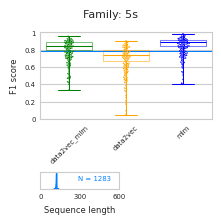

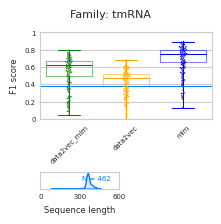

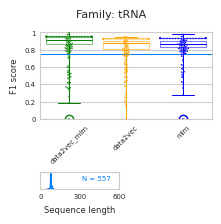

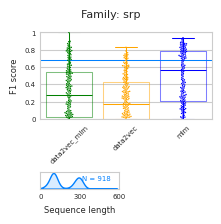

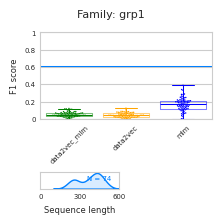

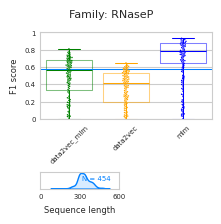

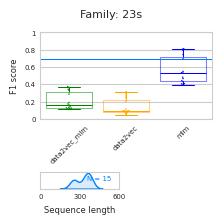

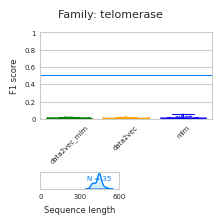

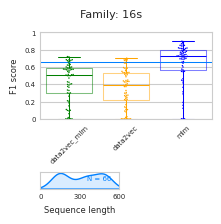

In [30]:

Ks = {
    "5s": 100,
    "16s": 100,
    "23s": 100,
    "RNaseP": 100,
    "grp1": 100,
    "srp": 150,
    "tRNA": 120,
    "telomerase": 120,
    "tmRNA": 90,
}

for fam in family:
    print(f"\n{fam}")
    boxplot_kde(fam=fam, K=Ks[fam], palette=framework_colors)